In [1]:
from pathlib import Path

In [2]:
modern_text = Path("ctl-modernist-fiction/clean00001261.txt").read_text(encoding="utf-8")

In [3]:
len(modern_text)

447440

In [4]:
print(modern_text[:500])

This etext was prepared from the 1896 Fredericke Warne & Co. edition by David Price, email ccx074@coventry.ac.uk A LADY OF QUALITY Being a most curious, hitherto unknown history, as related by Mr. Isaac Bickerstaff but not presented to the World of Fashion through the pages of The Tatler, and now for the first time written down by Francis Hodgson Burnett Were Nature just to Man from his first hour, he need not ask for Mercy; then 'tis for us--the toys of Nature--to be both just and merciful, for


In [5]:
nonmodern_text = Path("1895-1926-ctl-american-non-modernist/clean00001142.txt").read_text(encoding="utf-8")

In [6]:
len(nonmodern_text)

178285

In [7]:
import nltk

In [8]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to D:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
from nltk.tokenize import word_tokenize

In [10]:
modern_tokens = word_tokenize(modern_text)

In [11]:
len(modern_tokens)

99884

In [12]:
modern_tokens[:30]

['This',
 'etext',
 'was',
 'prepared',
 'from',
 'the',
 '1896',
 'Fredericke',
 'Warne',
 '&',
 'Co.',
 'edition',
 'by',
 'David',
 'Price',
 ',',
 'email',
 'ccx074',
 '@',
 'coventry.ac.uk',
 'A',
 'LADY',
 'OF',
 'QUALITY',
 'Being',
 'a',
 'most',
 'curious',
 ',',
 'hitherto']

In [13]:
nonmodern_tokens = word_tokenize(nonmodern_text)

In [14]:
len(nonmodern_tokens)

38962

In [15]:
# Clean: keep text starting from Chapter I
modern_start = modern_text.find("CHAPTER I")
nonmodern_start = nonmodern_text.find("CHAPTER I")

modern_text_clean = modern_text[modern_start:]
nonmodern_text_clean = nonmodern_text[nonmodern_start:]

In [16]:
modern_tokens = word_tokenize(modern_text_clean)
nonmodern_tokens = word_tokenize(nonmodern_text_clean)

In [17]:
modern_tokens[:30]

['CHAPTER',
 'I',
 '--',
 'The',
 'twenty-fourth',
 'day',
 'of',
 'November',
 '1690',
 'On',
 'a',
 'wintry',
 'morning',
 'at',
 'the',
 'close',
 'of',
 '1690',
 ',',
 'the',
 'sun',
 'shining',
 'faint',
 'and',
 'red',
 'through',
 'a',
 'light',
 'fog',
 ',']

In [18]:
nonmodern_tokens[:30]

['CHAPTER',
 'I',
 ':',
 'CORSICA',
 'TO',
 'BRIENNE',
 '1769-1779',
 'Napoleon',
 "'s",
 'father',
 ',',
 'Charles',
 'Bonaparte',
 ',',
 'was',
 'the',
 'honored',
 'progenitor',
 'of',
 'thirteen',
 'children',
 ',',
 'of',
 'whom',
 'the',
 'man',
 'who',
 'subsequently',
 'became',
 'the']

In [19]:
modern_tokens = [word.lower() for word in modern_tokens]
nonmodern_tokens = [word.lower() for word in nonmodern_tokens]

In [22]:
from nltk import FreqDist

modern_fdist = FreqDist(modern_words)
nonmodern_fdist = FreqDist(nonmodern_words)

modern_fdist.most_common(20)

[('and', 3907),
 ('the', 2976),
 ('her', 2716),
 ('to', 2115),
 ('she', 2066),
 ('a', 1829),
 ('of', 1792),
 ('was', 1375),
 ('in', 1249),
 ('he', 1163),
 ('that', 1060),
 ('had', 1030),
 ('i', 1026),
 ('it', 949),
 ('as', 933),
 ('his', 909),
 ('with', 884),
 ('not', 883),
 ('but', 708),
 ('so', 598)]

In [23]:
nonmodern_fdist.most_common(20)

[('the', 1785),
 ('of', 987),
 ('to', 949),
 ('and', 875),
 ('a', 698),
 ('i', 672),
 ('in', 497),
 ('that', 461),
 ('he', 459),
 ('it', 430),
 ('his', 416),
 ('you', 416),
 ('was', 373),
 ('for', 326),
 ('as', 294),
 ('is', 272),
 ('with', 272),
 ('said', 257),
 ('have', 254),
 ('napoleon', 213)]

In [24]:
modern_words = [word for word in modern_tokens if word.isalpha()]
nonmodern_words = [word for word in nonmodern_tokens if word.isalpha()]

In [25]:
len(modern_words), len(nonmodern_words)

(83732, 31403)

In [26]:
modern_words[:30]

['chapter',
 'i',
 'the',
 'day',
 'of',
 'november',
 'on',
 'a',
 'wintry',
 'morning',
 'at',
 'the',
 'close',
 'of',
 'the',
 'sun',
 'shining',
 'faint',
 'and',
 'red',
 'through',
 'a',
 'light',
 'fog',
 'there',
 'was',
 'a',
 'great',
 'noise',
 'of']

In [27]:
nonmodern_words[:30]

['chapter',
 'i',
 'corsica',
 'to',
 'brienne',
 'napoleon',
 'father',
 'charles',
 'bonaparte',
 'was',
 'the',
 'honored',
 'progenitor',
 'of',
 'thirteen',
 'children',
 'of',
 'whom',
 'the',
 'man',
 'who',
 'subsequently',
 'became',
 'the',
 'emperor',
 'of',
 'the',
 'french',
 'by',
 'some']

In [28]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        
        positions[word].append(index)
    
    return positions

In [29]:
modern_positions = get_word_positions(modern_words)
nonmodern_positions = get_word_positions(nonmodern_words)

In [30]:
modern_positions["the"][:20]

[2,
 11,
 14,
 39,
 105,
 116,
 174,
 177,
 184,
 202,
 231,
 254,
 272,
 276,
 297,
 345,
 349,
 352,
 385,
 398]

In [31]:
modern_positions["horse"][:20]

[285,
 721,
 867,
 1014,
 3081,
 4362,
 4459,
 4566,
 4787,
 4837,
 4908,
 6491,
 6502,
 6518,
 6524,
 6529,
 6572,
 6776,
 6827,
 7188]

In [32]:
modern_positions["child"][:20]

[475,
 1106,
 1162,
 1259,
 1290,
 1872,
 1964,
 1968,
 2015,
 2267,
 2442,
 2897,
 2980,
 3106,
 3255,
 3338,
 3540,
 5133,
 5436,
 6257]

In [33]:
def repetition_distances(position_list):
    distances = []

    for i in range(len(position_list) - 1):
        distance = position_list[i + 1] - position_list[i]
        distances.append(distance)

    return distances

In [34]:
repetition_distances([3, 10, 15, 30])

[7, 5, 15]

In [35]:
horse_distances = repetition_distances(modern_positions["horse"])

horse_distances[:30]

[436,
 146,
 147,
 2067,
 1281,
 97,
 107,
 221,
 50,
 71,
 1583,
 11,
 16,
 6,
 5,
 43,
 204,
 51,
 361,
 541,
 1059,
 9264,
 5906,
 1392,
 9431,
 37,
 294,
 186,
 10183,
 1140]

In [36]:
child_distances = repetition_distances(modern_positions["child"])

child_distances[:30]

[631,
 56,
 97,
 31,
 582,
 92,
 4,
 47,
 252,
 175,
 455,
 83,
 126,
 149,
 83,
 202,
 1593,
 303,
 821,
 641,
 255,
 283,
 143,
 419,
 104,
 696,
 319,
 8176,
 157,
 2528]

In [37]:
def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [38]:
average_distance([3, 10, 15, 30])

9.0

In [39]:
average_distance([3, 10, 15, 30])

9.0

In [40]:
average_distance(modern_positions["child"])

1104.1066666666666

In [41]:
def repetition_summary(word, positions):
    if word not in positions:
        print(word, "does not appear in this text.")
        return
    
    pos = positions[word]
    distances = repetition_distances(pos)
    avg_dist = average_distance(pos)
    
    print("Word:", word)
    print("Number of occurrences:", len(pos))
    print("First 30 positions:", pos[:30])
    print("First 30 repetition distances:", distances[:30])
    print("Average repetition distance:", avg_dist)

In [42]:
repetition_summary("horse", modern_positions)

Word: horse
Number of occurrences: 48
First 30 positions: [285, 721, 867, 1014, 3081, 4362, 4459, 4566, 4787, 4837, 4908, 6491, 6502, 6518, 6524, 6529, 6572, 6776, 6827, 7188, 7729, 8788, 18052, 23958, 25350, 34781, 34818, 35112, 35298, 45481]
First 30 repetition distances: [436, 146, 147, 2067, 1281, 97, 107, 221, 50, 71, 1583, 11, 16, 6, 5, 43, 204, 51, 361, 541, 1059, 9264, 5906, 1392, 9431, 37, 294, 186, 10183, 1140]
Average repetition distance: 1307.5106382978724


In [43]:
repetition_summary("child", modern_positions)

Word: child
Number of occurrences: 76
First 30 positions: [475, 1106, 1162, 1259, 1290, 1872, 1964, 1968, 2015, 2267, 2442, 2897, 2980, 3106, 3255, 3338, 3540, 5133, 5436, 6257, 6898, 7153, 7436, 7579, 7998, 8102, 8798, 9117, 17293, 17450]
First 30 repetition distances: [631, 56, 97, 31, 582, 92, 4, 47, 252, 175, 455, 83, 126, 149, 83, 202, 1593, 303, 821, 641, 255, 283, 143, 419, 104, 696, 319, 8176, 157, 2528]
Average repetition distance: 1104.1066666666666


In [44]:
"horse" in nonmodern_positions, "child" in nonmodern_positions

(True, True)

In [45]:
print("Modern text:")
repetition_summary("horse", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("horse", nonmodern_positions)

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [285, 721, 867, 1014, 3081, 4362, 4459, 4566, 4787, 4837, 4908, 6491, 6502, 6518, 6524, 6529, 6572, 6776, 6827, 7188, 7729, 8788, 18052, 23958, 25350, 34781, 34818, 35112, 35298, 45481]
First 30 repetition distances: [436, 146, 147, 2067, 1281, 97, 107, 221, 50, 71, 1583, 11, 16, 6, 5, 43, 204, 51, 361, 541, 1059, 9264, 5906, 1392, 9431, 37, 294, 186, 10183, 1140]
Average repetition distance: 1307.5106382978724

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [11217]
First 30 repetition distances: []
Average repetition distance: None


In [46]:
print("Modern text:")
repetition_summary("child", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("child", nonmodern_positions)

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [475, 1106, 1162, 1259, 1290, 1872, 1964, 1968, 2015, 2267, 2442, 2897, 2980, 3106, 3255, 3338, 3540, 5133, 5436, 6257, 6898, 7153, 7436, 7579, 7998, 8102, 8798, 9117, 17293, 17450]
First 30 repetition distances: [631, 56, 97, 31, 582, 92, 4, 47, 252, 175, 455, 83, 126, 149, 83, 202, 1593, 303, 821, 641, 255, 283, 143, 419, 104, 696, 319, 8176, 157, 2528]
Average repetition distance: 1104.1066666666666

Nonmodern text:
Word: child
Number of occurrences: 6
First 30 positions: [86, 428, 760, 2098, 2259, 15217]
First 30 repetition distances: [342, 332, 1338, 161, 12958]
Average repetition distance: 3026.2


In [47]:
modern_fdist.most_common(80)

[('and', 3907),
 ('the', 2976),
 ('her', 2716),
 ('to', 2115),
 ('she', 2066),
 ('a', 1829),
 ('of', 1792),
 ('was', 1375),
 ('in', 1249),
 ('he', 1163),
 ('that', 1060),
 ('had', 1030),
 ('i', 1026),
 ('it', 949),
 ('as', 933),
 ('his', 909),
 ('with', 884),
 ('not', 883),
 ('but', 708),
 ('so', 598),
 ('at', 596),
 ('him', 581),
 ('for', 572),
 ('you', 541),
 ('said', 508),
 ('be', 500),
 ('is', 474),
 ('have', 446),
 ('my', 403),
 ('would', 394),
 ('who', 390),
 ('all', 387),
 ('when', 371),
 ('there', 359),
 ('which', 353),
 ('were', 341),
 ('me', 338),
 ('been', 316),
 ('if', 315),
 ('this', 312),
 ('from', 309),
 ('they', 306),
 ('them', 305),
 ('by', 305),
 ('no', 299),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('on', 268),
 ('will', 257),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('or', 224),
 ('such', 216),
 ('their', 212),
 ('before', 198),
 ('like', 186),
 ('what', 185),
 ('lady', 178),
 ('clorinda', 174),
 ('being', 171),
 ('mo

In [48]:
words_to_compare = ["horse", "child", "woman", "man", "house", "room", "eyes", "hand", "day", "time"]

In [49]:
for word in words_to_compare:
    print("====================")
    print("WORD:", word)
    print()
    
    print("Modern text:")
    repetition_summary(word, modern_positions)
    print()
    
    print("Nonmodern text:")
    repetition_summary(word, nonmodern_positions)
    print()

WORD: horse

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [285, 721, 867, 1014, 3081, 4362, 4459, 4566, 4787, 4837, 4908, 6491, 6502, 6518, 6524, 6529, 6572, 6776, 6827, 7188, 7729, 8788, 18052, 23958, 25350, 34781, 34818, 35112, 35298, 45481]
First 30 repetition distances: [436, 146, 147, 2067, 1281, 97, 107, 221, 50, 71, 1583, 11, 16, 6, 5, 43, 204, 51, 361, 541, 1059, 9264, 5906, 1392, 9431, 37, 294, 186, 10183, 1140]
Average repetition distance: 1307.5106382978724

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [11217]
First 30 repetition distances: []
Average repetition distance: None

WORD: child

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [475, 1106, 1162, 1259, 1290, 1872, 1964, 1968, 2015, 2267, 2442, 2897, 2980, 3106, 3255, 3338, 3540, 5133, 5436, 6257, 6898, 7153, 7436, 7579, 7998, 8102, 8798, 9117, 17293, 17450]
First 30 repetition distances: [631, 56, 97, 31, 582, 92, 4, 47, 252, 175, 455, 83, 

In [50]:
def normalized_frequency(word, words):
    count = words.count(word)
    return count / len(words) * 1000

In [51]:
normalized_frequency("horse", modern_words)

0.5732575359480246

In [52]:
normalized_frequency("horse", nonmodern_words)

0.031844091328853935

In [53]:
def compare_word(word):
    print("Word:", word)
    print()
    
    print("Modern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, modern_words))
    
    if word in modern_positions:
        print("Average repetition distance:", average_distance(modern_positions[word]))
    else:
        print("Average repetition distance: None")
    
    print()
    
    print("Nonmodern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, nonmodern_words))
    
    if word in nonmodern_positions:
        print("Average repetition distance:", average_distance(nonmodern_positions[word]))
    else:
        print("Average repetition distance: None")

In [54]:
compare_word("horse")

Word: horse

Modern text:
Frequency per 1000 words: 0.5732575359480246
Average repetition distance: 1307.5106382978724

Nonmodern text:
Frequency per 1000 words: 0.031844091328853935
Average repetition distance: None


In [55]:
compare_word("child")

Word: child

Modern text:
Frequency per 1000 words: 0.907657765251039
Average repetition distance: 1104.1066666666666

Nonmodern text:
Frequency per 1000 words: 0.19106454797312358
Average repetition distance: 3026.2


In [56]:
compare_word("woman")

Word: woman

Modern text:
Frequency per 1000 words: 2.734916161085368
Average repetition distance: 363.7543859649123

Nonmodern text:
Frequency per 1000 words: 0.44581727860395504
Average repetition distance: 2305.6923076923076


In [57]:
print(
    f'{"Word":<10} {"Modern Freq":>12} {"Nonmodern Freq":>15} {"Modern Dist":>15} {"Nonmodern Dist":>18}'
)

print("-" * 75)

for word in words_to_compare:

    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    print(
        f"{word:<10} {modern_freq:>12.2f} {nonmodern_freq:>15.2f} {str(round(modern_dist,2)) if modern_dist else 'None':>15} {str(round(nonmodern_dist,2)) if nonmodern_dist else 'None':>18}"
    )

Word        Modern Freq  Nonmodern Freq     Modern Dist     Nonmodern Dist
---------------------------------------------------------------------------
horse              0.57            0.03         1307.51               None
child              0.91            0.19         1104.11             3026.2
woman              2.73            0.45          363.75            2305.69
man                2.85            1.97           350.9             506.31
house              0.87            0.29         1081.74            3575.12
room               0.64            0.29         1541.79            3221.75
eyes               2.70            0.19          367.86             4739.6
hand               1.64            0.57          606.37            1639.88
day                1.06            1.15          946.74             884.14
time               1.30            2.04          720.86             482.27


In [58]:
from pathlib import Path

modern_folder = Path("ctl-modernist-fiction")
nonmodern_folder = Path("1895-1926-ctl-american-non-modernist")

modern_files = list(modern_folder.glob("*.txt"))
nonmodern_files = list(nonmodern_folder.glob("*.txt"))

len(modern_files), len(nonmodern_files)

(41, 984)

In [59]:
modern_files_sample = modern_files[:10]
nonmodern_files_sample = nonmodern_files[:10]

modern_files_sample, nonmodern_files_sample

([WindowsPath('ctl-modernist-fiction/clean00001261.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001690.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001828.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001884.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002304.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002437.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002725.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002948.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002949.txt'),
  WindowsPath('ctl-modernist-fiction/clean00003082.txt')],
 [WindowsPath('1895-1926-ctl-american-non-modernist/clean00001142.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001156.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001160.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001161.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001162.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/cl

In [60]:
from nltk.tokenize import word_tokenize

def read_and_tokenize(file_path):
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    
    start = text.find("CHAPTER I")
    if start != -1:
        text = text[start:]
    
    tokens = word_tokenize(text)
    words = [word.lower() for word in tokens if word.isalpha()]
    
    return words

In [61]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        positions[word].append(index)
    
    return positions


def repetition_distances(position_list):
    distances = []
    
    for i in range(len(position_list) - 1):
        distances.append(position_list[i + 1] - position_list[i])
    
    return distances


def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [62]:
def text_repetition_features(file_path, label):
    words = read_and_tokenize(file_path)
    positions = get_word_positions(words)
    
    repeated_words = [word for word in positions if len(positions[word]) >= 2]
    
    repetition_rate = len(repeated_words) / len(set(words))
    
    all_distances = []
    for word in repeated_words:
        all_distances.extend(repetition_distances(positions[word]))
    
    if len(all_distances) > 0:
        avg_repetition_distance = sum(all_distances) / len(all_distances)
    else:
        avg_repetition_distance = None
    
    return {
        "file": file_path.name,
        "label": label,
        "total_words": len(words),
        "unique_words": len(set(words)),
        "repeated_words": len(repeated_words),
        "repetition_rate": repetition_rate,
        "avg_repetition_distance": avg_repetition_distance
    }

In [63]:
import pandas as pd

rows = []

for file in modern_files_sample:
    rows.append(text_repetition_features(file, "modernist"))

for file in nonmodern_files_sample:
    rows.append(text_repetition_features(file, "nonmodernist"))

df = pd.DataFrame(rows)

In [64]:
df.groupby("label")[[
    "total_words",
    "unique_words",
    "repeated_words",
    "repetition_rate",
    "avg_repetition_distance"
]].mean()

,total_words,unique_words,repeated_words,repetition_rate,avg_repetition_distance
label,,,,,
modernist,83132.0,7077.0,3751.6,0.51114,2196.201498
nonmodernist,67055.1,6467.1,3357.7,0.51197,1940.227861


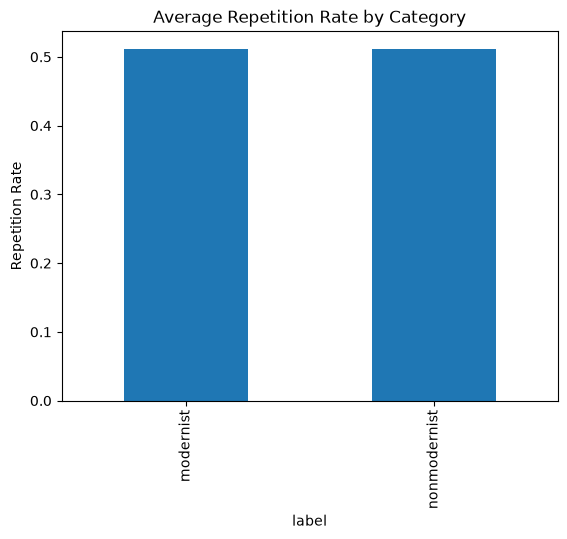

In [65]:
import matplotlib.pyplot as plt

df.groupby("label")["repetition_rate"].mean().plot(kind="bar")

plt.title("Average Repetition Rate by Category")
plt.ylabel("Repetition Rate")
plt.show()

In [66]:
from nltk import ConditionalFreqDist

text_word_pairs = []

for word in modern_words:
    text_word_pairs.append(("modern", word))

for word in nonmodern_words:
    text_word_pairs.append(("nonmodern", word))

cfd = ConditionalFreqDist(text_word_pairs)

In [67]:
cfd["modern"].most_common(20)

[('and', 3907),
 ('the', 2976),
 ('her', 2716),
 ('to', 2115),
 ('she', 2066),
 ('a', 1829),
 ('of', 1792),
 ('was', 1375),
 ('in', 1249),
 ('he', 1163),
 ('that', 1060),
 ('had', 1030),
 ('i', 1026),
 ('it', 949),
 ('as', 933),
 ('his', 909),
 ('with', 884),
 ('not', 883),
 ('but', 708),
 ('so', 598)]

In [68]:
cfd["nonmodern"].most_common(20)

[('the', 1785),
 ('of', 987),
 ('to', 949),
 ('and', 875),
 ('a', 698),
 ('i', 672),
 ('in', 497),
 ('that', 461),
 ('he', 459),
 ('it', 430),
 ('his', 416),
 ('you', 416),
 ('was', 373),
 ('for', 326),
 ('as', 294),
 ('is', 272),
 ('with', 272),
 ('said', 257),
 ('have', 254),
 ('napoleon', 213)]

Here I use ConditionalFreqDist to compare word frequency under two conditions: modern and nonmodern. 
This connects to the NLTK section on conditional frequency distributions, where a condition groups observations.
In my case, the condition is the text category, and the event is each word.

In [69]:
candidate_words = []

for word in modern_fdist:
    if modern_fdist[word] >= 20 and nonmodern_fdist[word] >= 1:
        candidate_words.append(word)

candidate_words = sorted(candidate_words)

len(candidate_words)

424

In [70]:
def word_feature_row(word):
    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    return [word, modern_freq, nonmodern_freq, modern_dist, nonmodern_dist]

In [71]:
feature_rows = []

for word in candidate_words:
    feature_rows.append(word_feature_row(word))

feature_rows[:10]

[['a',
  21.843500692686188,
  22.227175747540045,
  45.77297592997812,
  44.592539454806314],
 ['about',
  0.859886303922037,
  1.401140018469573,
  1171.5352112676057,
  662.0930232558139],
 ['after',
  0.6926861892705298,
  1.5922045664426967,
  1435.9649122807018,
  621.4285714285714],
 ['again',
  1.576458223857068,
  0.7324141005636404,
  627.9847328244275,
  1358.7272727272727],
 ['against',
  0.32245736397076386,
  0.31844091328853935,
  2828.269230769231,
  3102.6666666666665],
 ['air',
  0.4538288826255195,
  0.12737636531541574,
  2125.135135135135,
  4545.333333333333],
 ['all', 4.621888883580949, 3.598382320160494, 216.0, 275.66964285714283],
 ['almost',
  0.7643433812640328,
  0.031844091328853935,
  1234.7619047619048,
  None],
 ['alone',
  0.5254860746190225,
  0.15922045664426968,
  1853.1860465116279,
  6546.5],
 ['also', 0.418000286628768, 0.2865968219596854, 2289.029411764706, 3357.875]]

In [72]:
import pandas as pd

features_df = pd.DataFrame(
    feature_rows,
    columns=[
        "word",
        "modern_freq_per_1000",
        "nonmodern_freq_per_1000",
        "modern_avg_distance",
        "nonmodern_avg_distance"
    ]
)

features_df.head()

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance
0,a,21.843501,22.227176,45.772976,44.592539
1,about,0.859886,1.401140,1171.535211,662.093023
2,after,0.692686,1.592205,1435.964912,621.428571
3,again,1.576458,0.732414,627.984733,1358.727273
4,against,0.322457,0.318441,2828.269231,3102.666667


In [73]:
features_df["frequency_difference"] = (
    features_df["modern_freq_per_1000"] 
    - features_df["nonmodern_freq_per_1000"]
)

features_df.sort_values("frequency_difference", ascending=False).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
151,her,32.436822,1.241920,30.669982,788.315789,31.194903
306,she,24.673960,1.050855,40.276998,954.562500,23.623105
14,and,46.660775,27.863580,21.429595,35.719680,18.797195
133,had,12.301151,6.623571,81.186589,150.507246,5.677580
387,was,16.421440,11.877846,60.820961,84.376344,4.543594
317,so,7.141833,2.929656,140.093802,342.582418,4.212177
250,not,10.545550,6.432506,94.501134,155.368159,4.113044
154,him,6.938805,3.853135,143.487931,257.716667,3.085670
398,who,4.657717,2.038022,214.532134,493.873016,2.619696
92,eyes,2.699088,0.191065,367.857778,4739.600000,2.508023


This table helps me identify words that appear much more often in the modern text than in the nonmodern text.
However, frequency alone is not enough for my project, because I am interested in repetition as a pattern.
Therefore, I also compare average repetition distance.
A smaller average distance means that repeated words appear closer together.

In [74]:
modern_repetition_candidates = features_df[
    (features_df["modern_freq_per_1000"] > features_df["nonmodern_freq_per_1000"]) &
    (features_df["modern_avg_distance"] < features_df["nonmodern_avg_distance"])
]

modern_repetition_candidates.sort_values(
    "frequency_difference", 
    ascending=False
).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
151,her,32.436822,1.241920,30.669982,788.315789,31.194903
306,she,24.673960,1.050855,40.276998,954.562500,23.623105
14,and,46.660775,27.863580,21.429595,35.719680,18.797195
133,had,12.301151,6.623571,81.186589,150.507246,5.677580
387,was,16.421440,11.877846,60.820961,84.376344,4.543594
317,so,7.141833,2.929656,140.093802,342.582418,4.212177
250,not,10.545550,6.432506,94.501134,155.368159,4.113044
154,him,6.938805,3.853135,143.487931,257.716667,3.085670
398,who,4.657717,2.038022,214.532134,493.873016,2.619696
92,eyes,2.699088,0.191065,367.857778,4739.600000,2.508023


In [75]:
def split_into_chunks(words, chunk_size=1000):
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = words[i:i + chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

In [76]:
modern_chunks = split_into_chunks(modern_words, 1000)
nonmodern_chunks = split_into_chunks(nonmodern_words, 1000)

len(modern_chunks), len(nonmodern_chunks)

(83, 31)

In [77]:
def chunk_repetition_features(chunk):
    freq = FreqDist(chunk)

    repeated_words = [word for word in freq if freq[word] > 1]

    repeated_word_count = len(repeated_words)
    total_repetition_count = sum(freq[word] - 1 for word in repeated_words)
    unique_ratio = len(set(chunk)) / len(chunk)

    return {
        "repeated_word_count": repeated_word_count,
        "total_repetition_count": total_repetition_count,
        "unique_ratio": unique_ratio
    }

In [78]:
chunk_repetition_features(modern_chunks[0])

{'repeated_word_count': 128,
 'total_repetition_count': 592,
 'unique_ratio': 0.408}

In [79]:
rows = []

for chunk in modern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "modern"
    rows.append(features)

for chunk in nonmodern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "nonmodern"
    rows.append(features)

chunk_df = pd.DataFrame(rows)
chunk_df.head()

,repeated_word_count,total_repetition_count,unique_ratio,label
0,128,592,0.408,modern
1,133,578,0.422,modern
2,134,567,0.433,modern
3,132,609,0.391,modern
4,124,601,0.399,modern


In [80]:
chunk_df.groupby("label").mean()

,repeated_word_count,total_repetition_count,unique_ratio
label,,,
modern,131.325301,596.566265,0.403434
nonmodern,126.419355,566.354839,0.433645


This is my first classifier-style dataset. 
Each row represents a 1000-word section of a text.
Instead of classifying an entire book at once, I treat each chunk as a sample.
The features measure repetition: how many words repeat, how many repeated uses appear, and how diverse the vocabulary is.

<Axes: xlabel='label'>

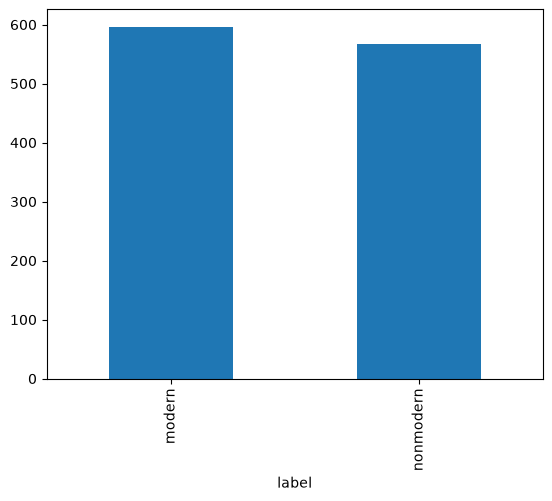

In [81]:
chunk_df.groupby("label")["total_repetition_count"].mean().plot(kind="bar")

At this stage, I am not claiming that repetition alone can classify modernism.
Instead, I am building measurable repetition features that could later become part of a classifier.
The next step would be to add more modernist and nonmodernist texts, because two texts are not enough to make a reliable classification model.